# Online Retail Sales Analysis — Beginner Project

**Tools:** Python, Pandas, Matplotlib and Jupyter Notebook.

**Goal:** Explore sales patterns and communicate useful observations about an online retailer.
This project uses basic data cleaning, grouping, sorting and charts. No SQL or machine learning is required.

### Our five questions
1. How did monthly sales change?
2. Which countries contributed the most sales?
3. Which products sold the most units?
4. Which weekdays had the most orders?
5. What were the typical order values?

### Data source and scope
[UCI Online Retail](https://archive.ics.uci.edu/dataset/352/online+retail),
Chen, D. (2015), DOI: https://doi.org/10.24432/C5BW33, licensed under
[CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).
The original file covers December 2010 to December 9, 2011. Each row is an **invoice line**, not a whole order.
Prices are in pounds sterling (GBP). We analyze January–November 2011 to compare complete calendar months.
This is historical practice data, not a description of today's retail market.

## 1. Import the tools and load the data
`pandas` works with tables. `matplotlib` draws charts. Run cells from top to bottom.
The Excel file is included in the `data` folder. Loading it can take a minute.

**Problem this solves:** Hundreds of thousands of invoice lines are too many to inspect or total manually. We need a repeatable way to read and summarize the same file.

**Why these methods were chosen:**
- **Pandas and `read_excel()`** load the supplied spreadsheet directly and provide simple table operations. There is no need for a database for this one-file exercise.
- **Jupyter Notebook** keeps code, results and explanations together, making each step easier to learn and review.
- **Matplotlib** creates the static charts needed for these questions and saves them as images for the report.
- **String types for invoice, product and customer IDs** treat these values as labels rather than measurements. This preserves letter prefixes such as `C` and avoids treating an identifier as a quantity.
- **`head()` and `shape`** provide a quick preview and row/column counts, helping confirm that the intended file and fields were loaded.
- **Relative paths and `mkdir(exist_ok=True)`** let the project run from its folder on another computer and create output folders without failing when they already exist.

**Limit:** A five-row preview cannot establish that the whole dataset is clean; the next step checks every row.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from IPython.display import display, Markdown

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (10, 5), 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.dpi': 110})
Path('charts').mkdir(exist_ok=True)
Path('outputs').mkdir(exist_ok=True)

df = pd.read_excel('data/Online Retail.xlsx',
                   dtype={'InvoiceNo': 'string', 'StockCode': 'string', 'CustomerID': 'string'})
print(f'Original data: {df.shape[0]:,} rows and {df.shape[1]} columns')
display(df.head())

Original data: 541,909 rows and 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


## 2. Inspect data quality
Check the file directly instead of assuming it is clean. `isna().sum()` counts missing values.
`duplicated().sum()` identifies repeated rows. A repeated row could be a real repeated invoice line,
so we retain these rows because there is no unique line ID to prove they are errors.
Missing customer IDs do not prevent a line from contributing to sales.

**Problem this solves:** Missing values, repeated records, unexpected quantities and incomplete date coverage can silently change the meaning of the results.

**Why these methods were chosen:**
- **`isna().sum()`** counts missing values for every column, showing which calculations need special handling. We keep missing customer IDs because sales value needs quantity and price, not customer identity. Dropping every row with any missing value would discard otherwise usable sales lines.
- **`duplicated().sum()`** measures exact repeated rows before making a cleaning decision. We retain them because identical lines are not sufficient proof of accidental duplication. This avoids deleting potentially real purchases, but totals could be inflated if those rows are errors.
- **`pd.to_datetime()`** gives dates a consistent date/time type so date filters and month/weekday extraction work reliably. It also fails on unparseable values instead of silently accepting them as valid dates.
- **Minimum and maximum dates** reveal the available time window and whether a final month is incomplete.
- **`describe()`** summarizes the count, spread and extremes of quantity and price. Negative values and very large maxima help identify records that need investigation without reading every line.

**Limit:** These are screening methods. A negative quantity may be a legitimate return, and a large order may be a wholesale purchase; neither automatically proves bad data.

In [2]:
display(df.isna().sum().rename('Missing values').to_frame())
print(f'Exact repeated rows (retained): {df.duplicated().sum():,}')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print('First invoice:', df['InvoiceDate'].min())
print('Last invoice:', df['InvoiceDate'].max())
display(df[['Quantity', 'UnitPrice']].describe())

,Missing values
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


Exact repeated rows (retained): 5,268
First invoice: 2010-12-01 08:26:00
Last invoice: 2011-12-09 12:50:00


,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


## 3. Select the sales records
For this exercise, **sales value** means `Quantity × UnitPrice` on positive-price,
positive-quantity lines from invoices that are not marked as cancellations.
We do not subtract returns, so this is **not net revenue or profit**. Cancellation invoice numbers start with `C`.
Other adjustments and charges may still be present in invoice totals.

Use January 1 through November 30, 2011. Keep unknown customers; this project does not analyze customer retention.
The cleaning table reports each filter in sequence so counts do not overlap.

**Problem this solves:** Mixing partial months, purchases, cancellations and non-positive lines would make a simple sales chart difficult to interpret consistently.

**Why these methods were chosen:**
- **January–November 2011** is a continuous set of complete months within one calendar year. December 2011 is incomplete; December 2010 is complete but outside the chosen 2011 scope. This reduces coverage differences, although months still have different lengths.
- **An inclusive start and exclusive end** (`>= '2011-01-01'` and `< '2011-12-01'`) include every time on November 30. A midnight cutoff on November 30 could accidentally omit most of that day.
- **Boolean filters** express the inclusion rules directly. Normalizing invoice IDs with `str.upper()` makes the cancellation-prefix check independent of letter case.
- **Positive quantity and price, excluding `C` invoices**, define a manageable beginner analysis of positive sales lines. The filters do not reconcile purchases against their later reversals: an original purchase can remain even when its cancellation is excluded.
- **`.copy()`** creates a separate working table, so adding calculated columns does not modify the original loaded table.
- **`Quantity * UnitPrice`** puts differently priced products on one monetary scale. For example, 3 units at GBP 4 each contribute GBP 12.
- **Year-month labels** keep months in different years separate. Weekday labels support the later weekday comparison.
- **Sequential remaining-row counts** show how much data each rule removes, without double-counting records that fail multiple rules.

**Limit:** These filters intentionally exclude some legitimate business activity. The result is included positive-line sales value, not a full accounting total. A net-revenue analysis would need a different treatment of returns and adjustments.

In [3]:
period = df[(df['InvoiceDate'] >= '2011-01-01') &
            (df['InvoiceDate'] < '2011-12-01')].copy()
not_cancelled = period[~period['InvoiceNo'].str.upper().str.startswith('C', na=False)].copy()
sales = not_cancelled[(not_cancelled['Quantity'] > 0) &
                      (not_cancelled['UnitPrice'] > 0)].copy()
sales['SalesValue'] = sales['Quantity'] * sales['UnitPrice']
sales['Month'] = sales['InvoiceDate'].dt.to_period('M').astype(str)
sales['Weekday'] = sales['InvoiceDate'].dt.day_name()

cleaning = pd.DataFrame({
    'Stage': ['Original rows', 'Jan–Nov 2011', 'After excluding C invoices',
              'After keeping positive quantity and price'],
    'Rows remaining': [len(df), len(period), len(not_cancelled), len(sales)]
})
display(cleaning)
cleaning.to_csv('outputs/cleaning_summary.csv', index=False)
print(f'Included sales lines without customer IDs: {sales["CustomerID"].isna().sum():,}')
print(f'Included exact repeated source rows: {sales.duplicated(subset=df.columns.tolist()).sum():,}')

,Stage,Rows remaining
0,Original rows,541909
1,Jan–Nov 2011,473903
2,After excluding C invoices,465703
3,After keeping positive quantity and price,463513


Included sales lines without customer IDs: 109,090
Included exact repeated source rows: 4,459


## 4. Calculate the main numbers
`sum()` adds values. `nunique()` counts distinct invoices.
Average order value is total included sales divided by the number of invoices with included lines.
It is not the average value of a single row.

**Problem this solves:** Counting rows confuses individual product lines with customer orders, while averaging line values gives the wrong answer for average order value.

**Why these methods were chosen:**
- **`sum()`** adds every included line value to measure the size of sales activity.
- **`InvoiceNo.nunique()`** counts each invoice once. An invoice containing five product lines is one order, not five orders.
- **Total sales divided by distinct invoices** calculates mean order value. It gives each order equal weight rather than each product line.
- **Grouping by invoice before taking the median** first reconstructs order values. The median describes the middle order and is less affected by a few unusually large purchases.

For example, two orders worth GBP 20 and GBP 80 have an average value of GBP 50, regardless of how many product lines each order contains.

**Limit:** These are order values after applying our line filters, not necessarily complete invoiced amounts. Neither the mean nor median tells us what causes customers to spend more.

In [4]:
total_sales = sales['SalesValue'].sum()
total_orders = sales['InvoiceNo'].nunique()
average_order = total_sales / total_orders
order_values = sales.groupby('InvoiceNo')['SalesValue'].sum()
median_order = order_values.median()

print(f'Included sales value: GBP {total_sales:,.2f}')
print(f'Included orders: {total_orders:,}')
print(f'Average order value: GBP {average_order:,.2f}')
print(f'Median order value: GBP {median_order:,.2f}')

Included sales value: GBP 9,204,145.72
Included orders: 17,582
Average order value: GBP 523.50
Median order value: GBP 305.48


## 5. Monthly sales
`groupby()` collects rows with the same month; `sum()` adds their sales values.
These are complete months. One year's pattern cannot establish that a change repeats every year.

**Problem this solves:** Individual transactions are too detailed to show the broad sales pattern over time.

**Why these methods were chosen:** `groupby('Month').sum()` reduces invoice lines to one total per month. `sort_index()` keeps the year-month labels in chronological order instead of ranking months by sales. A **line chart** emphasizes the sequence and changes between adjacent months; markers identify the observed monthly totals. Currency formatting makes large GBP values easier to read.

**What it helps answer:** Which months were relatively busy or quiet, and where should someone investigate promotions, stock availability or staffing?

**Limit:** Monthly totals are not normalized for the number of days or opening days. A rise does not prove that a promotion caused it, and eleven months cannot establish a recurring seasonal pattern.

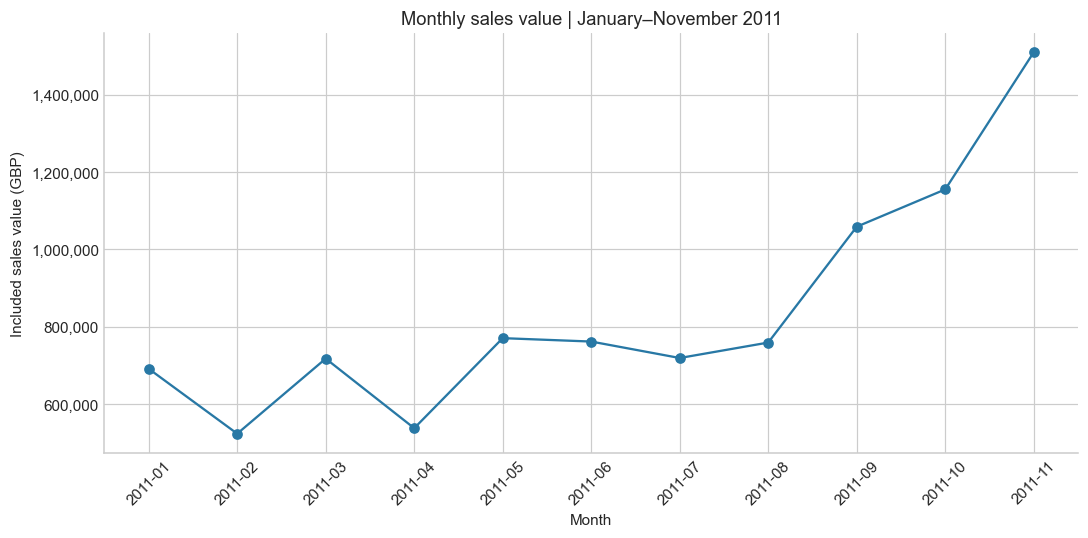

,SalesValue_GBP
Month,
2011-01,691364.56
2011-02,523631.89
2011-03,717639.36
2011-04,537808.62
2011-05,770536.02
2011-06,761739.90
2011-07,719221.19
2011-08,759138.38
2011-09,1058590.17


In [5]:
monthly = sales.groupby('Month')['SalesValue'].sum().sort_index()
ax = monthly.plot(kind='line', marker='o', color='#2878A5')
ax.set(title='Monthly sales value | January–November 2011',
       xlabel='Month', ylabel='Included sales value (GBP)')
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.xticks(range(len(monthly)), monthly.index, rotation=45)
plt.tight_layout()
plt.savefig('charts/01_monthly_sales.png')
plt.show()
display(monthly.round(2).rename('SalesValue_GBP').to_frame())
monthly.to_csv('outputs/monthly_sales.csv', header=['SalesValue_GBP'])

## 6. Top countries
Country refers to the customer's country. The chart shows the ten largest by included sales value,
not the size of the overall market in those countries.

**Problem this solves:** We need to identify where this retailer's recorded sales are concentrated without presenting a crowded chart of every country.

**Why these methods were chosen:** Grouping by country and summing **sales value** measures monetary contribution; a row count would measure invoice lines instead. Sorting and selecting the **top ten** produces a readable ranking. A **horizontal bar chart** gives country names room and makes category values easy to compare on a common scale. Sorting the displayed bars in ascending order places the largest at the top.

**What it helps answer:** How dependent are the included sales on a small number of countries? The full country summary is exported so smaller countries are still available for review.

**Limit:** The chart does not show profitability, market share or the potential of a new market. Customer country is also not proof of delivery destination.

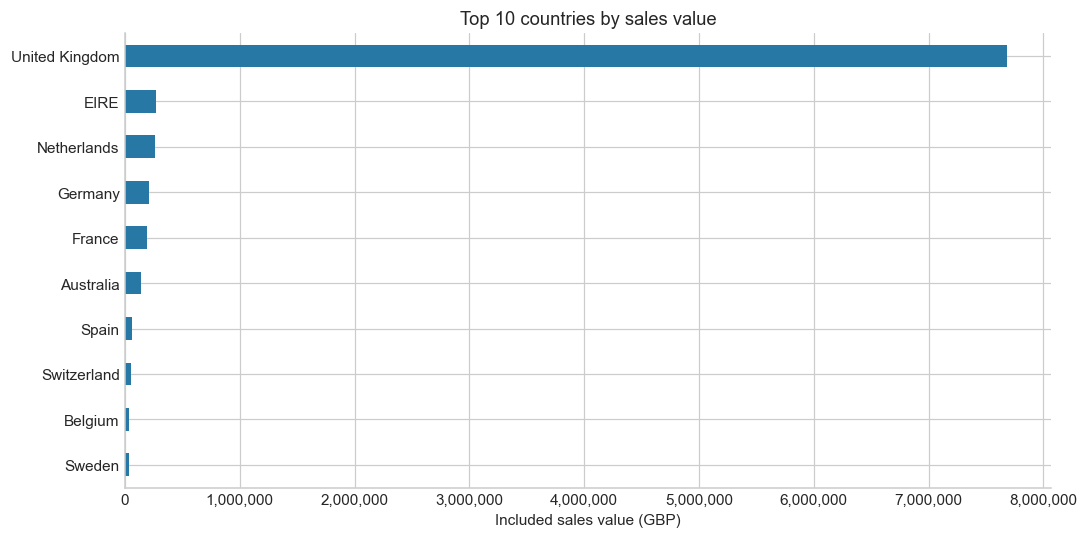

In [6]:
countries = sales.groupby('Country')['SalesValue'].sum().sort_values(ascending=False)
ax = countries.head(10).sort_values().plot(kind='barh', color='#2878A5')
ax.set(title='Top 10 countries by sales value', xlabel='Included sales value (GBP)', ylabel='')
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.savefig('charts/02_top_countries.png')
plt.show()
countries.to_csv('outputs/country_sales.csv', header=['SalesValue_GBP'])

## 7. Top products by quantity
Product descriptions can vary, so group by `StockCode` and attach a description for display.
For this product chart only, use codes containing five digits and optional letter suffixes.
This simple documented rule excludes special codes such as postage or manual charges; it is not a verified product catalogue.
Invoice totals elsewhere keep all otherwise eligible lines.

**Problem this solves:** A product can appear under different descriptions, and invoice lines can also contain items such as postage. We need a reasonably consistent way to rank product volume.

**Why these methods were chosen:**
- **Grouping by `StockCode`** combines lines for the same identifier even when descriptions differ. Grouping by description could split one product into several entries.
- **`str.fullmatch()`** applies a transparent five-digit-code rule with optional letter suffixes. It helps exclude special service codes before ranking products. This is a simple heuristic, not a confirmed catalogue classification.
- **Summing quantity** answers which products have the most units on included lines. Counting rows would ignore the number of units per line; summing sales value would answer a different question about money.
- **`first()` and `join()`** attach the first available description to each product code for readable labels. The code remains visible because the chosen description is only a display label.
- **A horizontal top-ten bar chart** supports long product names and makes the highest volumes easy to compare.
- **`fillna('Unknown')`** supplies a display label where a description is missing; it does not invent product information.

**Limit:** Some real products may fail the code rule, and some non-product codes may pass it. The rule only affects this product chart. Quantities are not net of returns, so investigate unusual orders before interpreting the ranking as demand.

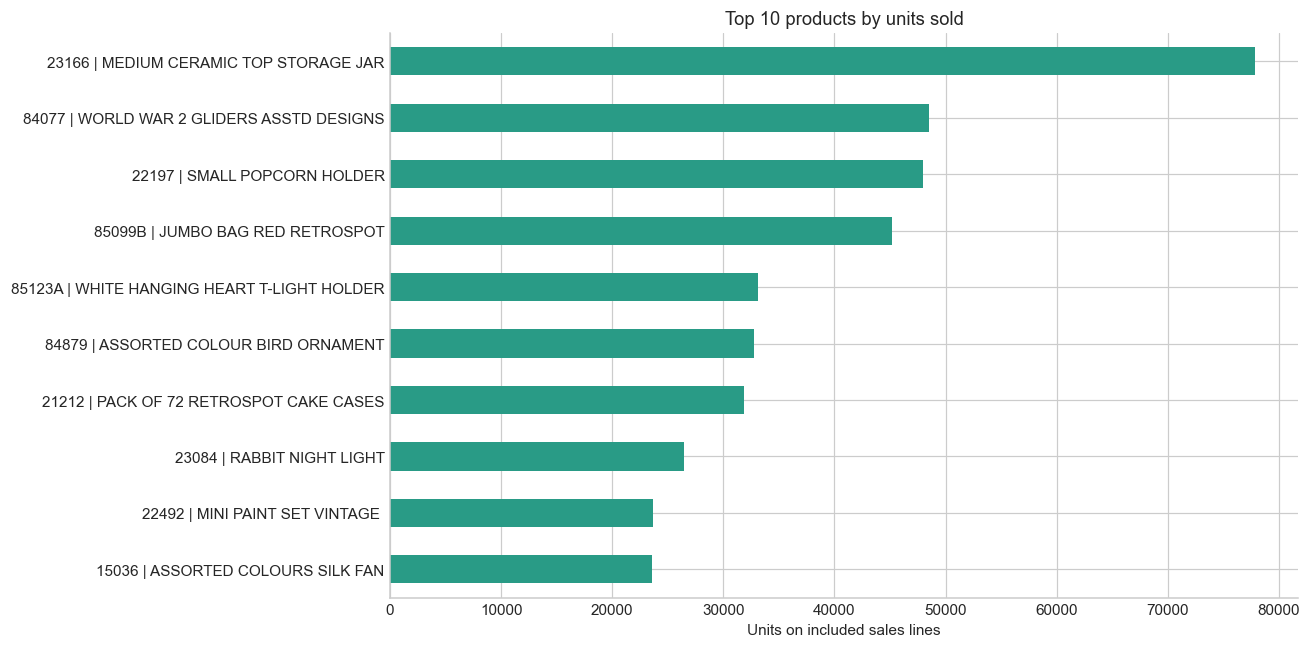

In [7]:
products = sales[sales['StockCode'].str.fullmatch(r'\d{5}[A-Za-z]*', na=False)].copy()
product_units = products.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False)
names = products.groupby('StockCode')['Description'].first()
top_products = product_units.head(10).rename('Units').to_frame().join(names)
top_products['Label'] = top_products.index + ' | ' + top_products['Description'].fillna('Unknown')
ax = top_products.sort_values('Units').plot.barh(x='Label', y='Units', legend=False,
                                               color='#299B86', figsize=(12, 6))
ax.set(title='Top 10 products by units sold', xlabel='Units on included sales lines', ylabel='')
plt.tight_layout()
plt.savefig('charts/03_top_products.png')
plt.show()
top_products.drop(columns='Label').to_csv('outputs/top_products.csv')

### Check an unusually large line before interpreting the ranking
Sorting quantities reveals whether one invoice dominates a product's total. Look for a possible reversal
with the same product, customer, price and opposite quantity in the original period data.
This is an investigation clue, not a complete returns-matching system. We keep the stated positive-line
definition throughout, so this ranking must not be interpreted as net product demand.

**Problem this solves:** A single extreme line can make a product appear to be a strong seller even if that order was later reversed.

**Why these methods were chosen:** Sorting quantities and displaying the largest three lines is an easy-to-follow first check for a beginner. The largest line is then compared with the original period table, which still contains negative quantities. Matching **product, customer, price and opposite quantity** provides stronger evidence of a possible reversal than matching the product alone.

**What the result means here:** The saved output identifies a 74,215-unit line and one possible reversal record. That is a reason to investigate the leading product before recommending more stock. It is not a reason to silently remove the record from an analysis with already-declared inclusion rules.

**Limit:** This check investigates only the largest quantity line. It does not match every return, check the order of the transaction dates, or establish a unique purchase-to-return link. Missing IDs, partial returns and repeated purchases also require more careful handling in a full reconciliation.

In [8]:
largest_line = sales.sort_values('Quantity', ascending=False).iloc[0]
columns = ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice', 'InvoiceDate', 'CustomerID']
display(sales.sort_values('Quantity', ascending=False)[columns].head(3))
possible_reversals = period[
    (period['StockCode'] == largest_line['StockCode']) &
    (period['CustomerID'] == largest_line['CustomerID']) &
    (period['UnitPrice'] == largest_line['UnitPrice']) &
    (period['Quantity'] == -largest_line['Quantity'])
]
print('Possible reversal records for the largest quantity line:')
display(possible_reversals[columns])
outlier_note = (f"The largest included line contains {int(largest_line['Quantity']):,} units of "
                f"stock {largest_line['StockCode']}. There are {len(possible_reversals)} possible "
                "reversal records with matching customer, product, price and opposite quantity. "
                "Investigate these before treating the product ranking as demand or making stock decisions.")
print(outlier_note)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,InvoiceDate,CustomerID
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,2011-01-18 10:01:00,12346
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,2011-10-27 12:26:00,12901
206121,554868,22197,SMALL POPCORN HOLDER,4300,0.72,2011-05-27 10:52:00,13135


Possible reversal records for the largest quantity line:


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,InvoiceDate,CustomerID
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1.04,2011-01-18 10:17:00,12346


The largest included line contains 74,215 units of stock 23166. There are 1 possible reversal records with matching customer, product, price and opposite quantity. Investigate these before treating the product ranking as demand or making stock decisions.


## 8. Orders by weekday
Count distinct invoice numbers instead of rows. This reports total recorded orders for each weekday,
not orders per opening day. A zero does not prove that customer demand is zero.

**Problem this solves:** Counting product rows could make a weekday with large multi-item orders look busier than a weekday with more actual orders.

**Why these methods were chosen:** `groupby('Weekday')['InvoiceNo'].nunique()` measures distinct recorded orders for each weekday. **`reindex()` with Monday-to-Sunday labels** uses familiar calendar order instead of alphabetical order. Filling absent groups with zero shows that no eligible orders were recorded for that weekday. A **bar chart** compares these discrete categories without suggesting a continuous time series.

**What it helps answer:** Which weekdays account for the most orders in this period, as a starting point for reviewing workload?

**Limit:** These are totals, not average orders per open day. Different numbers of occurrences, opening schedules and holidays can affect the comparison. A zero may reflect closure or data coverage rather than a lack of demand.

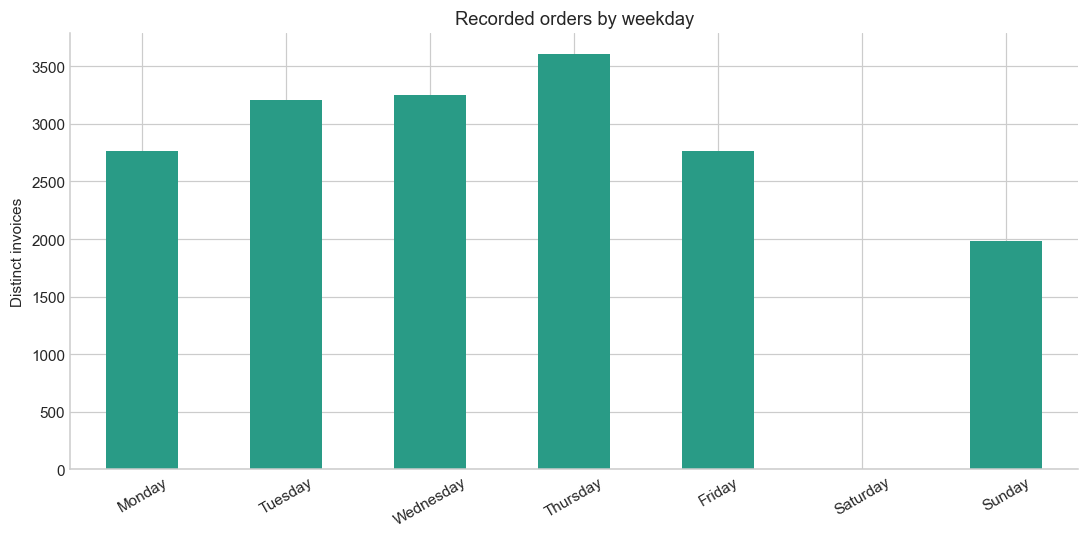

In [9]:
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_orders = sales.groupby('Weekday')['InvoiceNo'].nunique().reindex(weekdays, fill_value=0)
ax = weekday_orders.plot(kind='bar', color='#299B86', rot=30)
ax.set(title='Recorded orders by weekday', xlabel='', ylabel='Distinct invoices')
plt.tight_layout()
plt.savefig('charts/04_weekday_orders.png')
plt.show()
weekday_orders.to_csv('outputs/weekday_orders.csv', header=['Orders'])

## 9. Order values
A histogram shows how many orders fall into each value range.
For readability, plot only orders at or below the 95th percentile. The title reports the number shown.
Large orders remain in all metrics, including the mean and median printed earlier.
The median is the middle order value and is less affected by very large orders.

**Problem this solves:** A single average hides the distribution of order values, and a few very large orders can stretch the chart until most orders are hard to see.

**Why these methods were chosen:** A **histogram** groups numeric order values into ranges and counts the orders in each range. This reveals concentration and spread that a mean alone cannot show. **Thirty bins** are a practical readability choice for this chart, not a statistically optimized setting; changing the bin count changes its appearance.

The **95th-percentile cutoff** limits only the displayed data so the central bulk of orders is easier to inspect. Values equal to the cutoff are retained, so the exact fraction displayed can differ slightly from 95%. The title and printed count disclose what is omitted. The earlier mean, median and total still use all eligible orders.

**Limit:** This chart cannot describe the omitted upper tail. For a complete view of extremes, inspect all order values separately, use a suitable transformed scale, or add a second chart. The cutoff is not a cleaning rule or proof that large orders are invalid.

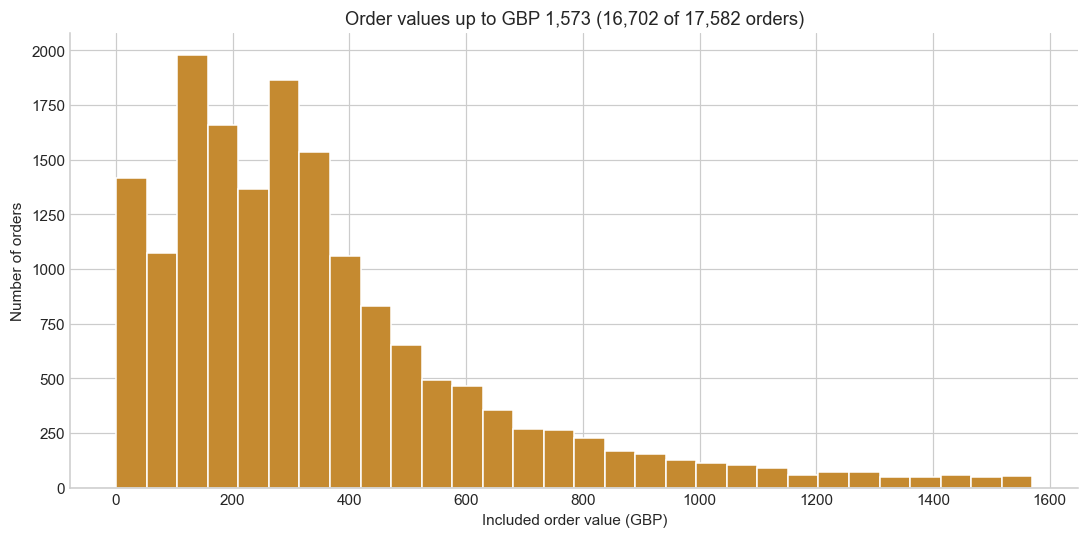

880 larger orders are outside this chart.


In [10]:
cutoff = order_values.quantile(0.95)
visible_orders = order_values[order_values <= cutoff]
ax = visible_orders.plot(kind='hist', bins=30, color='#C58A30', edgecolor='white')
ax.set(title=f'Order values up to GBP {cutoff:,.0f} ({len(visible_orders):,} of {len(order_values):,} orders)',
       xlabel='Included order value (GBP)', ylabel='Number of orders')
plt.tight_layout()
plt.savefig('charts/05_order_values.png')
plt.show()
print(f'{len(order_values) - len(visible_orders):,} larger orders are outside this chart.')

## 10. Findings and possible actions
The text below uses the calculated results, so rerunning the notebook updates the numbers.
Actions are suggestions to investigate, not evidence of achieved improvements.

**Problem this solves:** Charts alone leave readers to guess what matters, while manually copied findings can become inconsistent when the data or filters change.

**Why these methods were chosen:** Python **f-strings** insert computed figures directly into the written findings. **`idxmax()`** identifies the label associated with a maximum, and dividing a country's value by total sales expresses its contribution as a percentage. Formatting rounds numbers for display while calculations retain their original precision.

Each action is framed as a follow-up investigation, such as checking stock and returns before changing purchasing. This connects the result to a business decision while making the missing evidence explicit.

**Limit:** These descriptive summaries identify patterns, not causes. They do not demonstrate that a proposed action will improve revenue or profit. Maximum-label methods select one result if values tie; a fuller analysis should inspect ties when they matter.

In [11]:
top_country = countries.index[0]
country_share = countries.iloc[0] / total_sales * 100
top_product = top_products.iloc[0]
findings = f"""# Findings — Online Retail Sales Analysis

Scope: January–November 2011; positive-quantity, positive-price, non-cancellation invoice lines.
Sales value excludes the effect of returns and is not profit or net revenue. Exact repeated rows are retained.

1. Included sales total **GBP {total_sales:,.2f}** across **{total_orders:,} invoices**.
2. **{monthly.idxmax()}** has the highest monthly sales value, **GBP {monthly.max():,.2f}**.
3. **{top_country}** contributes **{country_share:.1f}%** of included sales value.
4. **{top_product['Description']}** (code {top_products.index[0]}) leads the eligible product codes with **{int(top_product['Units']):,} units**.
5. **{weekday_orders.idxmax()}** has the most recorded orders: **{int(weekday_orders.max()):,}**.
6. Mean order value is **GBP {average_order:,.2f}** and the median is **GBP {median_order:,.2f}**.

**Outlier check:** {outlier_note}

## Suggested next steps for a business
- Review inventory for the highest-volume products; check stock availability and returns before increasing purchases.
- Compare the busiest month and weekdays with opening hours, promotions and staffing records before changing staffing.
- Investigate dependence on the leading country; compare delivery costs and margins before choosing markets for expansion.

## Limitations
- Historical data from one retailer; some buyers are wholesalers. Results do not represent all online retail.
- Returns/cancellations are excluded instead of reconciled to purchases. No profit, retention or causal claims are made.
- Missing customer IDs are retained for sales analysis. Exact repeated rows may affect totals if they are errors.
- Product-code filtering is a simple heuristic; non-product charges may remain in invoice-level sales totals.
- No cost, stock, promotion or opening-hours data is available. A single year cannot establish recurring seasonality.
- The histogram omits orders above the 95th percentile visually only; all orders remain in summary metrics.
"""
display(Markdown(findings))
Path('outputs/findings.md').write_text(findings, encoding='utf-8')

# Findings — Online Retail Sales Analysis

Scope: January–November 2011; positive-quantity, positive-price, non-cancellation invoice lines.
Sales value excludes the effect of returns and is not profit or net revenue. Exact repeated rows are retained.

1. Included sales total **GBP 9,204,145.72** across **17,582 invoices**.
2. **2011-11** has the highest monthly sales value, **GBP 1,509,496.33**.
3. **United Kingdom** contributes **83.5%** of included sales value.
4. **MEDIUM CERAMIC TOP STORAGE JAR** (code 23166) leads the eligible product codes with **77,826 units**.
5. **Thursday** has the most recorded orders: **3,608**.
6. Mean order value is **GBP 523.50** and the median is **GBP 305.48**.

**Outlier check:** The largest included line contains 74,215 units of stock 23166. There are 1 possible reversal records with matching customer, product, price and opposite quantity. Investigate these before treating the product ranking as demand or making stock decisions.

## Suggested next steps for a business
- Review inventory for the highest-volume products; check stock availability and returns before increasing purchases.
- Compare the busiest month and weekdays with opening hours, promotions and staffing records before changing staffing.
- Investigate dependence on the leading country; compare delivery costs and margins before choosing markets for expansion.

## Limitations
- Historical data from one retailer; some buyers are wholesalers. Results do not represent all online retail.
- Returns/cancellations are excluded instead of reconciled to purchases. No profit, retention or causal claims are made.
- Missing customer IDs are retained for sales analysis. Exact repeated rows may affect totals if they are errors.
- Product-code filtering is a simple heuristic; non-product charges may remain in invoice-level sales totals.
- No cost, stock, promotion or opening-hours data is available. A single year cannot establish recurring seasonality.
- The histogram omits orders above the 95th percentile visually only; all orders remain in summary metrics.


2076

## 11. Check and export
These checks confirm that summaries agree and the selected rows obey our rules.
The cleaned CSV can be opened in Excel; the original Excel file remains unchanged.

**Problem this solves:** A chart can look plausible even if records were accidentally dropped, counted twice or filtered inconsistently. Readers also need files they can inspect outside the notebook.

**Why these methods were chosen:**
- **Assertions on eligible rows** confirm that the working table actually follows the positive-value, non-cancellation and non-missing-invoice rules.
- **The eleven-month check** verifies that every month in the chosen window appears. It does not prove every transaction within those months is present.
- **Comparing monthly, country and invoice sums with the overall total** checks that these summaries account for the same sales value. A tolerance smaller than GBP 0.01 avoids failures from tiny floating-point arithmetic differences while requiring totals to agree within a penny.
- **Comparing weekday order counts with the overall invoice count** helps catch an invoice being counted across multiple weekdays or omitted from the weekday summary.
- **CSV tables** make the calculated results available for Excel or later analysis. The generated cleaned CSV is excluded from Git because the notebook recreates it; the original data and small summary tables are included.
- **Saved PNG charts and the HTML report** let someone review the results without running Python. The original Excel file remains available so the cleaning decisions can be revisited.

**Limit:** Internal agreement does not establish external accuracy. These checks cannot prove that the source file is complete, repeated rows are legitimate, or the chosen business definitions are appropriate for another use.

In [12]:
assert len(sales) > 0
assert sales['Quantity'].gt(0).all() and sales['UnitPrice'].gt(0).all()
assert not sales['InvoiceNo'].str.upper().str.startswith('C').any()
assert sales['InvoiceNo'].notna().all()
assert len(monthly) == 11
assert abs(monthly.sum() - total_sales) < 0.01
assert abs(countries.sum() - total_sales) < 0.01
assert abs(order_values.sum() - total_sales) < 0.01
assert weekday_orders.sum() == total_orders

sales.to_csv('outputs/cleaned_sales.csv', index=False)
summary = pd.DataFrame({'Metric': ['Sales value (GBP)', 'Orders', 'Mean order value (GBP)',
                                   'Median order value (GBP)'],
                        'Value': [round(total_sales, 2), total_orders,
                                  round(average_order, 2), round(median_order, 2)]})
summary.to_csv('outputs/key_metrics.csv', index=False)
print('All consistency checks passed. Charts and tables are saved.')

All consistency checks passed. Charts and tables are saved.


## Practice before your interview
1. Explain why `InvoiceNo.nunique()` counts orders more accurately than counting rows.
2. Explain why returns are excluded and why you should not call these results net revenue.
3. Change the country chart from the top 10 to the top 5 and rerun it.
4. Make a product chart ranked by sales value instead of units. Explain why the rankings can differ.
5. Explain the difference between mean and median order value in your own words.
6. Describe one limitation and what extra data would help address it.

You should be able to explain and modify the notebook before presenting it as your portfolio work.